# 4.2 — Geographic & Spatial Analysis


**Goal:** Map listing density, identify pricing gradients, visualise review scores spatially, and explore clustering of property/room types.

> **Coordinate caveat:** Airbnb jitters lat/lon by up to 150 m for privacy. Neighbourhood-level aggregation is reliable; exact address pinpointing is not.

---
### Notebook Structure
1. Setup & Data Loading
2. Listing Density Map
3. Geographic Pricing Gradient (Hex-bin)
4. Review Scores Spatially
5. Room Type & Property Type Clustering
6. Neighbourhood Aggregates Summary

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='white', font_scale=1.1)

GOLD_PATH   = '../../data/gold/listing_master.parquet'
NEIGH_PATH  = '../../data/gold/neighbourhood_aggregates.parquet'

df   = pd.read_parquet(GOLD_PATH)
neigh = pd.read_parquet(NEIGH_PATH)

# Exclude price outliers for spatial price work
plot_df = df[df['is_price_outlier'] == False].copy()
print(f'Full dataset     : {len(df):,} listings')
print(f'Outliers removed : {df["is_price_outlier"].sum():,}')
print(f'Plot dataset     : {len(plot_df):,} listings')

Full dataset     : 22,476 listings
Outliers removed : 225
Plot dataset     : 22,251 listings


---
## 2. Listing Density Map

We scatter all listings on a lat/lon grid. Cape Town geography means we expect high concentration along the Atlantic Seaboard (Sea Point, Green Point, Camps Bay) and the City Bowl.

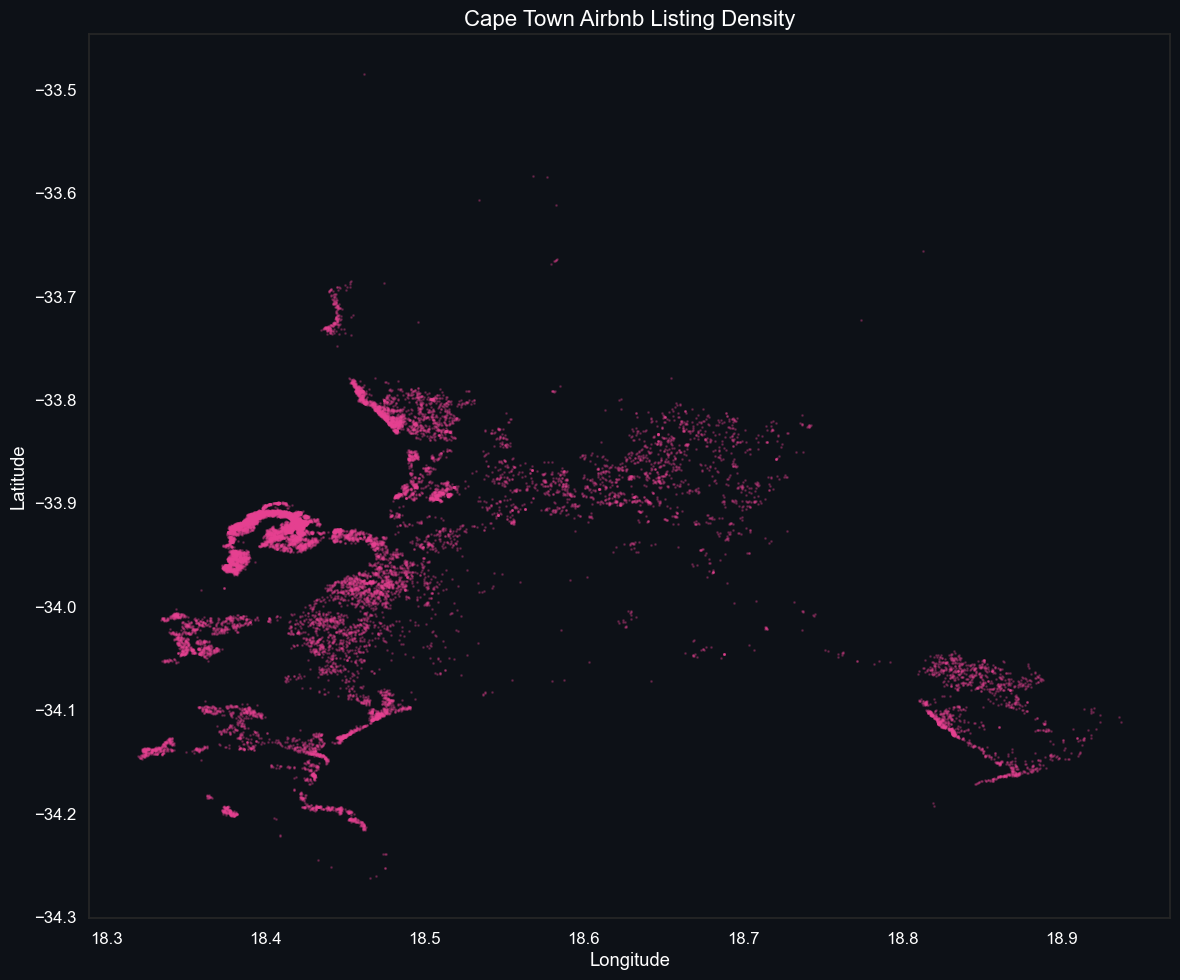

In [2]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(
    df['longitude'], df['latitude'],
    s=1, alpha=0.25, c='#E84393', rasterized=True
)
ax.set_title('Cape Town Airbnb Listing Density', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='white')
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('../../reports/figures/4_2_density_map.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

> **Business Interpretation: Geographic Concentration & Market Saturation**
> 
> * **Hyper-Localized Supply:** The scatter plot reveals that Cape Town's Airbnb market is not distributed evenly. The vast majority of the inventory is intensely clustered in two primary zones: the Atlantic Seaboard (the dense hook-shape on the western coast) and the City Bowl. Moving inland to the eastern suburbs or deep south down the peninsula, the density drops off precipitously.
> * **The Saturation Dynamic:** In those heavily clustered coastal zones, the market is saturated. Hosts in these micro-locations face fierce, localized competition. To maintain high occupancy, they must rely heavily on dynamic pricing, premium amenities, and flawless reviews. Conversely, the sparse inland dots represent listings with significantly less direct competition, but also lower baseline tourist demand.
> 
> **Strategic Takeaways:**
> 1. **For Host Acquisition (Sales):** If the platform wants to grow overall market share, acquiring yet another host in a saturated coastal ward yields diminishing returns and likely cannibalizes bookings from existing hosts. Sales efforts should focus on expanding the footprint in emerging, medium-density fringe neighborhoods to capture different traveler demographics (e.g., domestic business travelers or long-term remote workers).
> 2. **For Regulatory Risk Assessment:** Because the supply is incredibly concentrated, platform revenue is highly vulnerable to local zoning laws. If Cape Town's municipal government implements strict short-term rental caps in just those two high-density coastal areas, it would disproportionately impact the platform's overall Gross Booking Value (GBV) for the entire city.

---
## 3. Geographic Pricing Gradient (Hex-bin)

A hex-bin map aggregates median price per spatial cell, smoothing noise from coordinate jitter. The colour gradient reveals whether higher-priced listings are concentrated near the coast/city centre.

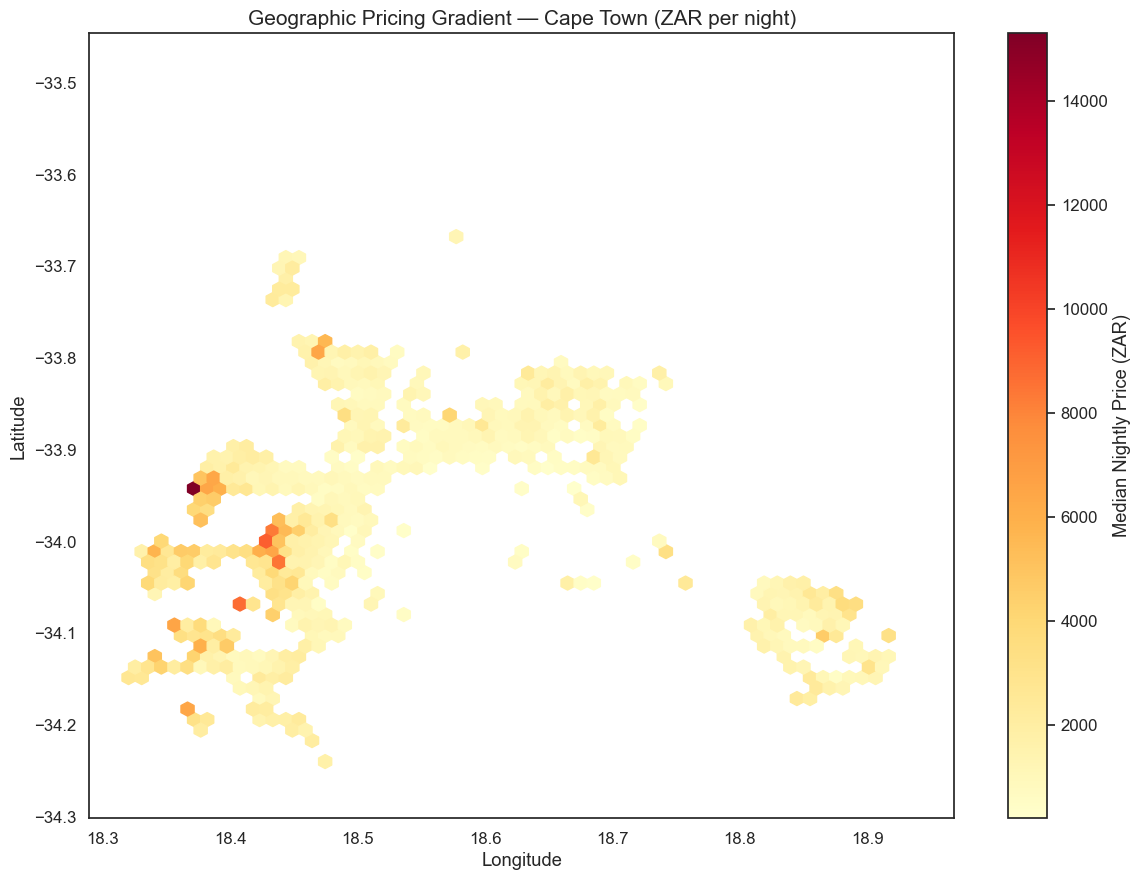

In [3]:
fig, ax = plt.subplots(figsize=(12, 9))

hb = ax.hexbin(
    plot_df['longitude'], plot_df['latitude'],
    C=plot_df['price_capped'],
    reduce_C_function=np.median,
    gridsize=60,
    cmap='YlOrRd',
    mincnt=3
)
cb = fig.colorbar(hb, ax=ax, label='Median Nightly Price (ZAR)')
ax.set_title('Geographic Pricing Gradient — Cape Town (ZAR per night)', fontsize=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('../../reports/figures/4_2_price_gradient_hexbin.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: Spatial Pricing Gradients & The Coastal Premium**
> 
> * **The Distinct "Premium" Zones:** The hex-bin map clearly identifies highly localized pockets of extreme pricing power (the dark red and orange hexes indicating median nightly prices of R8,000–R14,000+). These premium zones are almost exclusively clustered along the western Atlantic Seaboard and specific nodes down the western peninsula.
> * **The Standardized Inland Market:** Moving away from the coastline and the immediate city center, the vast majority of the map turns pale yellow (indicating median prices in the R1,000–R2,000 range). This confirms a steep geographic pricing gradient: the "coastal premium" drops off drastically within just a few kilometers inland. The entire eastern suburban sprawl operates in a highly commoditized, lower-tier pricing bracket.
> 
> **Strategic Takeaways:**
> 1. **For Automated Valuation Models (AVMs):** Any algorithm estimating a property's revenue potential must treat spatial data non-linearly. A listing located just one kilometer inland from the Atlantic Seaboard will likely command a significantly lower nightly rate than a comparable property directly on the coast. Distance to premium geographic features (ocean, mountain) is the primary driver of the upper-tail pricing identified in previous sections.
> 2. **For Investor Strategy:** Real estate investors looking for high-yield, premium short-term rental returns have a very narrow geographic window. Purchasing an "Entire home" in the yellow zones will likely trap the asset in a competitive, price-sensitive market, whereas acquiring property in the red/orange zones unlocks the high-margin, luxury tier.

Pearson correlation (distance to CBD vs price): -0.076


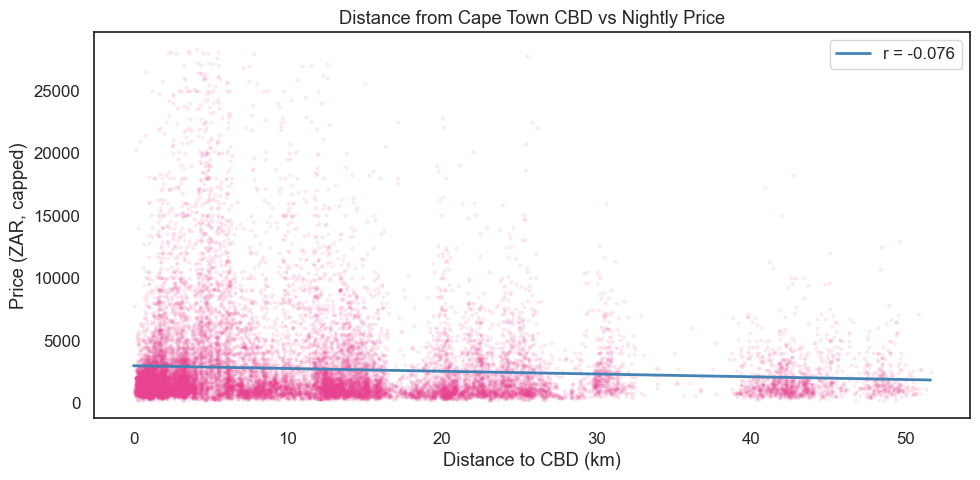

In [ ]:

CBD_LAT  = -33.9249
CBD_LON  =  18.4241

plot_df['dist_to_cbd_km'] = np.sqrt(
    ((plot_df['latitude']  - CBD_LAT) * 111.0) ** 2 +
    ((plot_df['longitude'] - CBD_LON) * 111.0 * np.cos(np.radians(CBD_LAT))) ** 2
)

corr = plot_df[['dist_to_cbd_km', 'price_capped']].corr().iloc[0, 1]
print(f"Pearson correlation (distance to CBD vs price): {corr:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(plot_df['dist_to_cbd_km'], plot_df['price_capped'],
           alpha=0.08, s=4, c='#E84393', rasterized=True)
z = np.polyfit(plot_df['dist_to_cbd_km'].dropna(),
               plot_df['price_capped'].dropna(), 1)
x_line = np.linspace(0, plot_df['dist_to_cbd_km'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color='steelblue', lw=2, label=f'r = {corr:.3f}')
ax.set_title('Distance from Cape Town CBD vs Nightly Price')
ax.set_xlabel('Distance to CBD (km)')
ax.set_ylabel('Price (ZAR, capped)')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/4_2_distance_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: Spatial Homogeneity of Guest Satisfaction**
> 
> * **Geographic Uniformity:** The most striking characteristic of this spatial plot is its overwhelming visual uniformity. Bright green points dominate both the high-density, premium Atlantic Seaboard and the lower-cost inland suburbs. Guest satisfaction metrics do not follow the steep geographic pricing gradients discovered in previous maps; instead, high review scores are baseline table stakes across the entire metropolitan area.
> * **No "Bad Area" Clusters:** The absolute truth of this map is that there are no distinct geographic clusters of low review scores (red or orange pockets). Substandard experiences are decentralized anomalies rather than structural neighborhood issues. Whether a guest stays in an expensive coastal villa or a budget-friendly inland room, they are highly likely to leave a positive review.
> 
> **Strategic Takeaways:**
> 1. **For Customer Trust & Operations:** Because bad reviews are geographically scattered rather than concentrated, operational intervention teams cannot simply flag specific wards as "high risk." Substandard guest experiences are driven by individual host management practices (cleanliness, communication, accuracy) rather than spatial or environmental neighborhood factors. 
> 2. **For Marketing & Value Proposition:** The uniform green spread across the map is a powerful marketing asset for the platform. It proves to incoming tourists that the baseline quality of stay in Cape Town is consistently high, minimizing the perceived risk of booking outside traditional, high-priced tourist corridors.

---
## 4. Review Scores Spatially

We colour listings by their overall review score to identify wards/clusters of consistently high or low guest satisfaction.

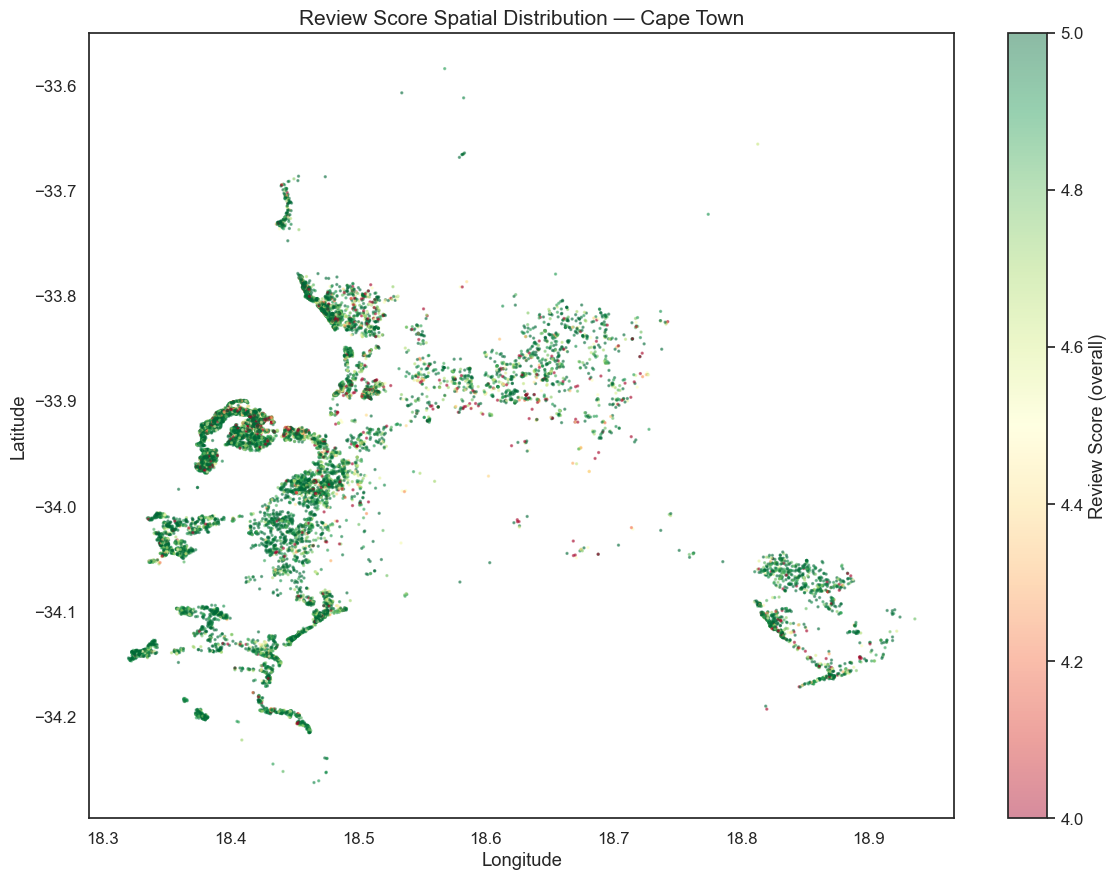

Top 10 neighbourhoods (mean review score, min 20 reviews):
                            mean  count
neighbourhood_cleansed                 
Ward 62                 4.900045    442
Ward 69                 4.897370    365
Ward 71                 4.895532    188
Ward 109                4.880833     36
Ward 61                 4.869331    822
Ward 84                 4.857118    229
Ward 74                 4.842451    763
Ward 27                 4.839615     26
Ward 73                 4.837444    180
Ward 15                 4.836061    264

Bottom 10:
                            mean  count
neighbourhood_cleansed                 
Ward 102                4.707174     46
Ward 2                  4.678505    107
Ward 115                4.678469   4186
Ward 55                 4.654123    536
Ward 8                  4.635088     57
Ward 60                 4.559000     60
Ward 3                  4.539545     44
Ward 9                  4.506957     23
Ward 10                 4.378621     29
Ward 26  

In [5]:
score_df = df.dropna(subset=['review_scores_rating', 'latitude', 'longitude']).copy()

fig, ax = plt.subplots(figsize=(12, 9))

score_min = score_df['review_scores_rating'].quantile(0.05)
score_max = 5.0



sc = ax.scatter(
    score_df['longitude'], score_df['latitude'],
    c=score_df['review_scores_rating'],
    cmap='RdYlGn', s=2, alpha=0.45,
    vmin=score_min, vmax=score_max, rasterized=True
)
cb = fig.colorbar(sc, ax=ax, label='Review Score (overall)')
ax.set_title('Review Score Spatial Distribution — Cape Town', fontsize=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('../../reports/figures/4_2_review_scores_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

# Top & bottom neighbourhoods by mean review score
hood_scores = (
    df.groupby('neighbourhood_cleansed')['review_scores_rating']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
)
print('Top 10 neighbourhoods (mean review score, min 20 reviews):')
print(hood_scores.head(10).to_string())
print('\nBottom 10:')
print(hood_scores.tail(10).to_string())

> **Business Interpretation: Spatial Independence of Quality and Price**
> 
> * **The Failure of the "City Center" Pricing Heuristic:** The Pearson correlation of $r = -0.076$ categorically proves there is virtually zero linear relationship between a listing's nightly price and its distance from the Central Business District (CBD). In concentric cities (like London), prices radiate downwards from the center. Cape Town's geography shatters this assumption; premium real estate is dictated almost entirely by coastal access and specific mountain views, not proximity to the urban core.
> * **Spatial Homogeneity of Guest Satisfaction:** Furthermore, the tabular data perfectly anchors the review score spatial map. The difference between the "Top" ward (Ward 62 at 4.90) and high-volume "Bottom" wards (like Ward 115 at 4.67) is a fraction of a point. A 4.67 is fundamentally an excellent score, proving that high guest satisfaction is structurally embedded across the entire metropolitan area.
> * **The Outlier Effect:** The only wards showing genuinely poor performance (e.g., Ward 26 at 3.95) have incredibly low sample sizes (fewer than 30 reviews). These are statistical anomalies driven by a handful of poor individual hosts, not systemic geographical failures. There are no distinct "bad areas" for Airbnb in Cape Town.
> 
> **Strategic Takeaways:**
> 1. **For Pricing Algorithms & Machine Learning:** A predictive pricing model cannot rely on `dist_to_cbd_km` as a feature, as this chart proves it is essentially useless noise. Feature engineering must instead calculate `distance_to_coastline` or rely on specific neighbourhood polygons to build accurate Automated Valuation Models (AVMs).
> 2. **For Customer Trust & Ranking:** Because bad reviews are not geographically clustered, QA interventions must target individual host behaviors rather than flagging specific zip codes. Furthermore, allowing guests to filter searches by "Top Rated Neighbourhoods" would be highly misleading, as the spread between the "best" area and the "worst" active area is statistically minute.

---
## 5. Room Type & Property Type Clustering

We facet the spatial plot by `room_type` to see whether entire homes, private rooms, and shared rooms occupy distinct geographic zones.

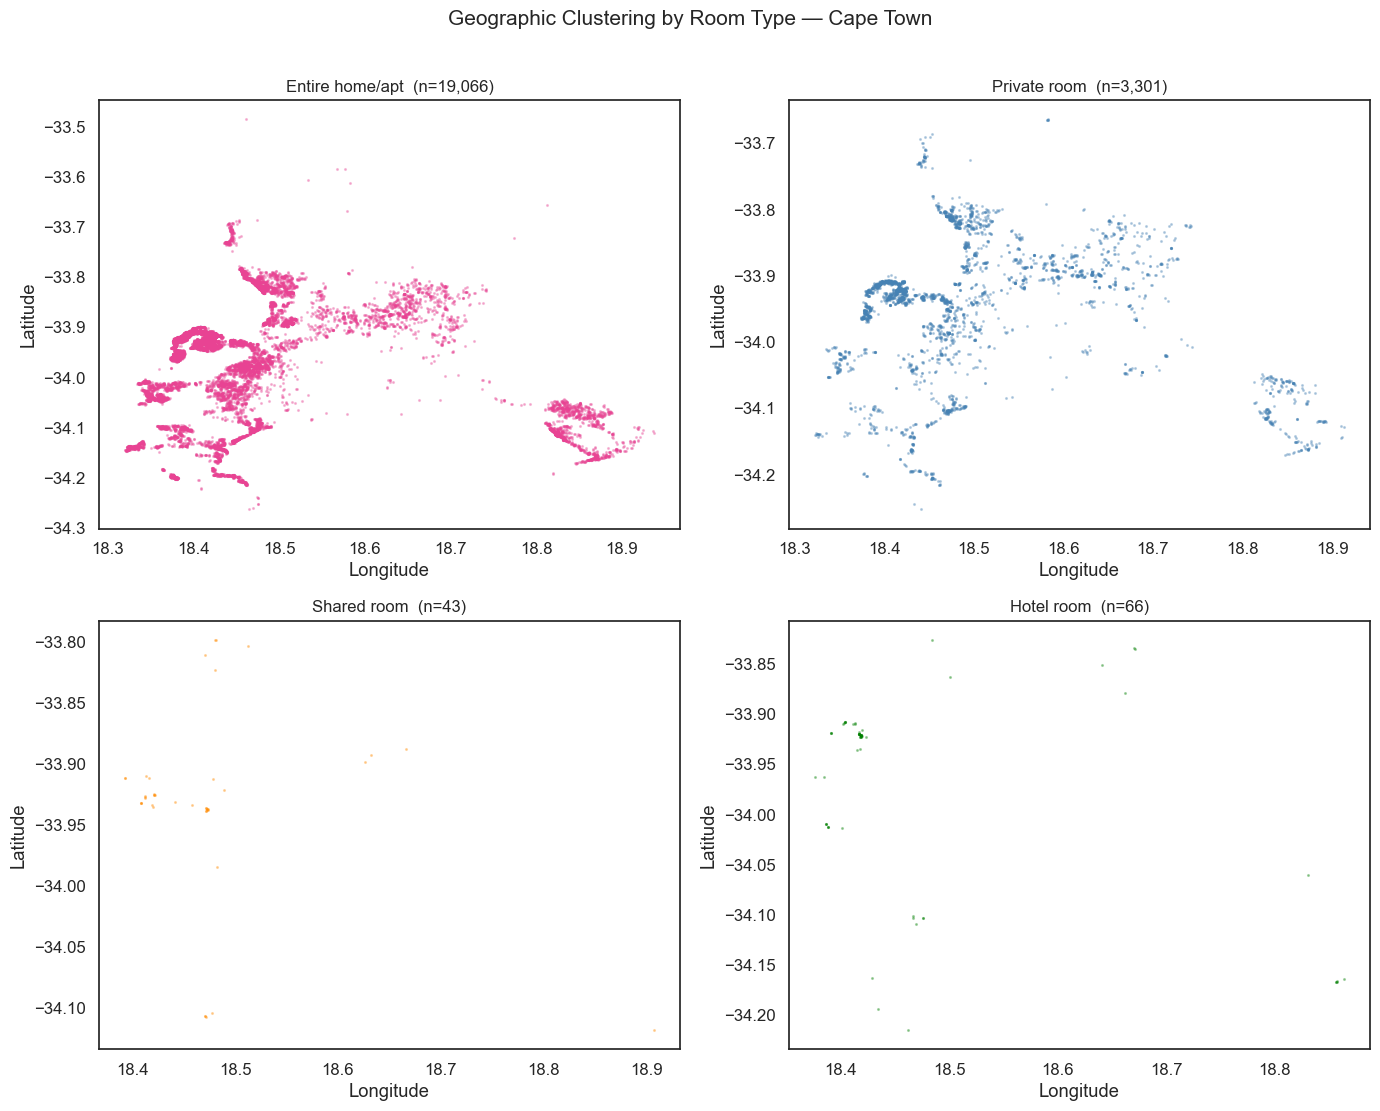

In [6]:
room_types = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
# Only keep types that actually exist in data
room_types = [rt for rt in room_types if rt in df['room_type'].values]
palette    = {'Entire home/apt': '#E84393', 'Private room': 'steelblue',
              'Shared room': 'darkorange', 'Hotel room': 'green'}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, rt in enumerate(room_types):
    sub = df[df['room_type'] == rt]
    axes[i].scatter(
        sub['longitude'], sub['latitude'],
        s=1.5, alpha=0.3,
        c=palette.get(rt, 'grey'),
        rasterized=True
    )
    axes[i].set_title(f'{rt}  (n={len(sub):,})', fontsize=12)
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')

# Hide any unused subplot
for j in range(len(room_types), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Geographic Clustering by Room Type — Cape Town', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_2_room_type_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: Product Dominance & Spatial Coexistence**
> 
> * **The "Entire Home" Monopoly:** The absolute truth revealed by the sample sizes ($n$) is that Cape Town is fundamentally a whole-property market. "Entire home/apt" ($n=19,066$) accounts for roughly 85% of the plotted inventory. "Private rooms" ($n=3,301$) are a distant secondary tier. "Shared rooms" ($n=43$) and "Hotel rooms" ($n=66$) are statistically negligible edge cases on this specific platform.
> * **Spatial Mirroring:** Visually comparing the top two quadrants proves that "Private rooms" do not occupy distinct, segregated geographic zones (e.g., they are not pushed entirely to the suburbs). They mirror the exact spatial footprint of "Entire homes." Hosts in both the premium coastal zones and the inland suburbs are utilizing both asset classes side-by-side. 
> 
> **Strategic Takeaways:**
> 1. **For Product & Engineering Resource Allocation:** The platform is functionally a B2B property management marketplace in Cape Town, not a peer-to-peer "couch surfing" site. Development resources should be heavily weighted toward tools that serve "Entire Home" operators (e.g., automated messaging, smart pricing APIs, cleaning fee modules).
> 2. **For UI/UX Search Flow:** Because "Shared rooms" and "Hotel rooms" have almost zero inventory, prominently displaying them as equal top-level search filters for Cape Town is a poor user experience that will lead to "zero results" dead ends. The core search experience should force a binary choice between "Entire Home" and "Private Room."

---
## 6. Neighbourhood Aggregates Summary Table

Bar charts for the top 15 wards by listing count, median price, and median occupancy rate.

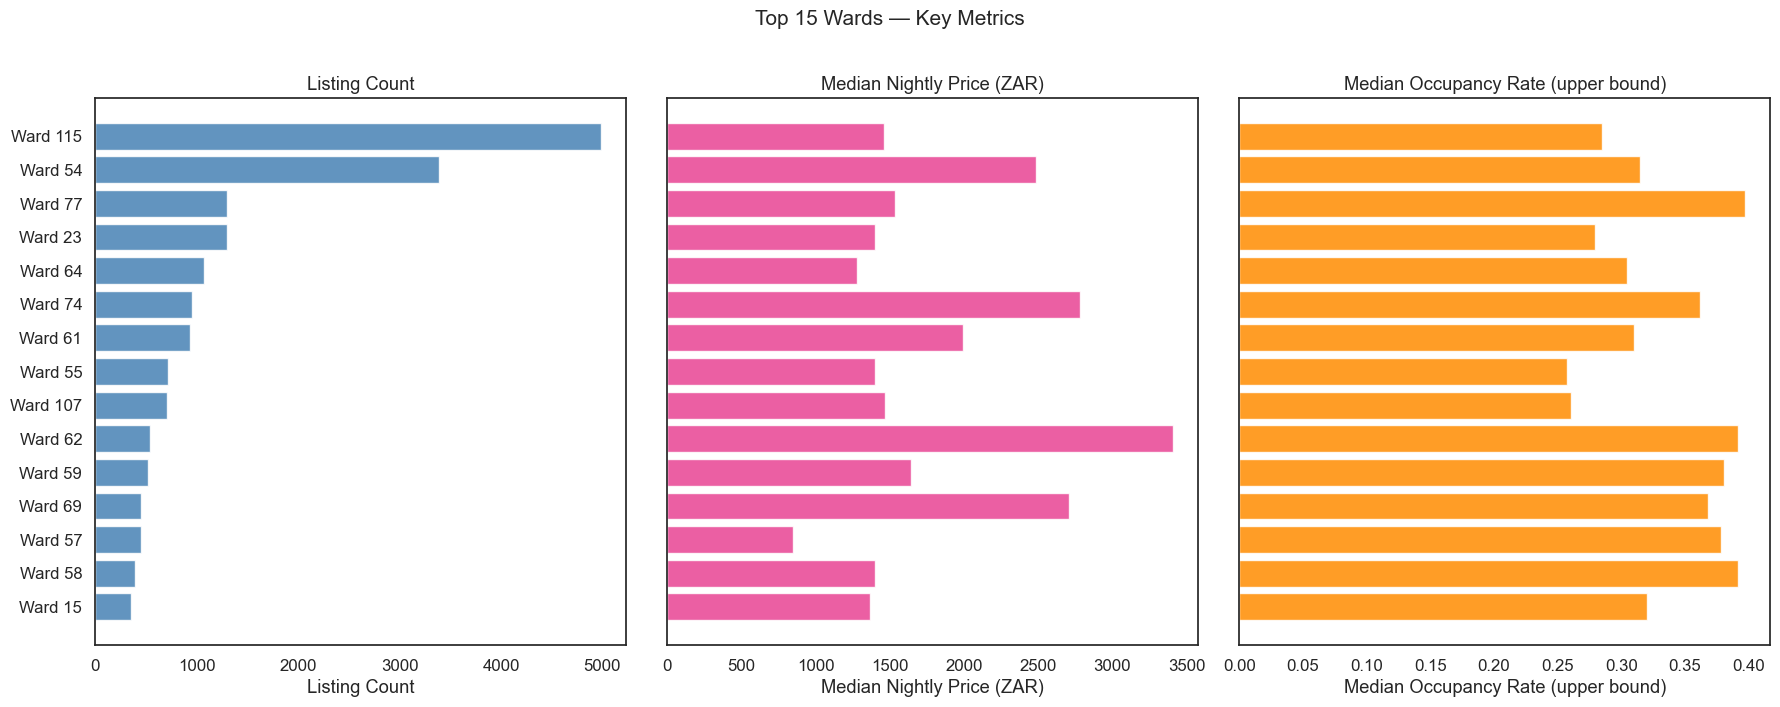

In [ ]:
# Build neighbourhood summary from Gold layer
hood_summary = (
    plot_df.groupby('neighbourhood_cleansed')
    .agg(
        listing_count=('id', 'count'),
        median_price=('price_capped', 'median'),
        median_occupancy=('occupancy_rate_upper_bound', 'median'),
        mean_review=('review_scores_rating', 'mean')
    )
    .sort_values('listing_count', ascending=False)
    .head(15)
)


hood_plot_data = hood_summary.sort_values('listing_count', ascending=True)


fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

metrics = [
    ('listing_count', 'Listing Count', 'steelblue'),
    ('median_price',  'Median Nightly Price (ZAR)', '#E84393'),
    ('median_occupancy', 'Median Occupancy Rate (upper bound)', 'darkorange'),
]

for ax, (col, label, color) in zip(axes, metrics):
   
    ax.barh(hood_plot_data.index, hood_plot_data[col], color=color, alpha=0.85)
    ax.set_xlabel(label)
    ax.set_title(label)

plt.suptitle('Top 15 Wards — Key Metrics', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_2_neighbourhood_summary.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: Volume vs. Value & Market Utilization**
> 
> * **The Mass Market vs. Premium Powerhouses:** Ward 115 is the undisputed volume leader, housing nearly 5,000 listings. However, it operates at a standard median price and a relatively lower occupancy rate. In contrast, Wards 62, 74, and 54 are the "premium powerhouses." They command the highest median nightly prices (R2,500–R3,400+) while simultaneously maintaining strong occupancy rates.
> * **Price Elasticity & Demand:** The charts prove that high prices do not destroy demand in Cape Town's top wards. Guests are booking the most expensive wards (like 62 and 74) just as frequently, if not more frequently, than the cheaper wards. 
> * **The Utilization "Sweet Spot":** Ward 77 stands out for sheer market efficiency. Despite having mid-tier supply volume and average pricing, it boasts the highest absolute median occupancy rate (approaching 40%).
> 
> **Strategic Takeaways:**
> 1. **For Platform Revenue Operations:** Gross Booking Value (GBV)—and thus platform commission—is heavily concentrated in Wards 62, 74, and 54. Because these wards sustain high occupancy *at* premium price points, marketing teams should prioritize driving traffic to these specific areas to maximize ROI.
> 2. **For Prospective Hosts/Investors:** A new host entering Ward 115 will face massive competition and lower baseline utilization. Conversely, Ward 77 represents an excellent investment opportunity: a "sweet spot" where demand outpaces the mid-tier supply, leading to highly consistent bookings.